In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1.

To implement RK-2, firstly I'll need to split the second order differential equation $y''(t)=-g$ into two coupled first order ones as such:
\begin{equation}
    \frac{dy}{dt} = v
\end{equation}
\begin{equation}
    \frac{dv}{dt} = -g
\end{equation}
Which I can then solve simultaneously by defing $\textbf{r} = (y(t), v(t))$.

40.0


Text(0, 0.5, 'y(t)')

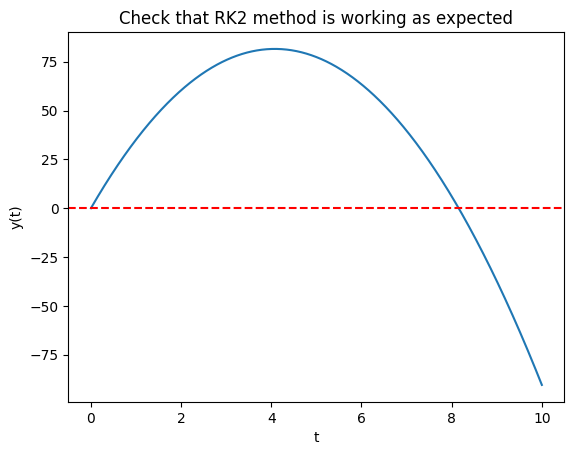

In [2]:
g = 9.81 # m/s^2

def f(r):
    y = r[0]
    v = r[1]

    fy = v
    fv = -g

    return np.array([fy,fv])

# implement RK-2
def RK2(v0):
    # discretize t grid from 0 to 10
    t_i = 0
    t_f = 10
    n = 1001
    h = (t_f-t_i)/(n-1)

    t = np.linspace(t_i,t_f,n)

    # create y and v arrays
    y = np.zeros(n)
    v = np.zeros(n)
    y[0] = 0
    v[0] = v0

    r = np.array([y[0],v[0]])

    for i in range(n-1):
        k1 = f(r)
        k2 = f(r+k1*h/2)

        r = r + h*k2

        y[i+1] = r[0]
        v[i+1] = r[1]

    return t, y, v

# check the RK2 is working as expected
t, y_check, v_check = RK2(40)

print(v_check[0])
plt.plot(t, y_check)
plt.axhline(y=0, ls='--', c='r')
plt.title('Check that RK2 method is working as expected')
plt.xlabel('t')
plt.ylabel('y(t)')

The RK2 function seems to be working fine since the resulting function seems to be parabolic. 

To implement the secant shooting method, I'll define $g(\alpha) = u_{\alpha}(x_{n-1}) - y(x_{n-1})$ where $\alpha$ is the shooting parameter, in this case the initial velocity, and $u_{\alpha}$ is the solution using $v(0) = \alpha$. Since $y(x_{n-1}) = 0$ for this problem, I just need to return $u_{\alpha}(x_{n-1})$.

49.050000000000225


Text(0, 0.5, 'y(t)')

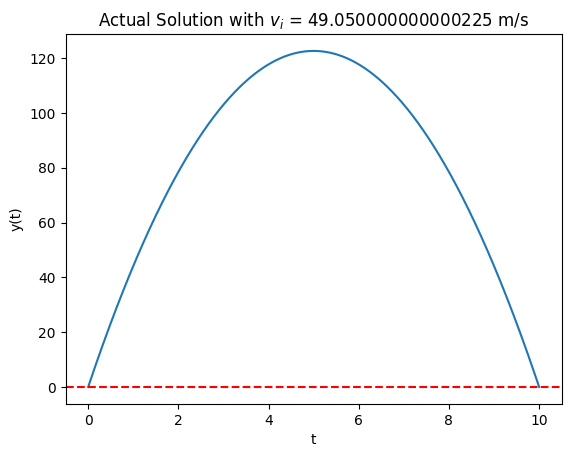

In [14]:
# define g function and return u(x_n-1)
def ga(alpha):
    t, y, v = RK2(alpha)
    return y[-1]

# implement secant method to solve for the shooting parameter
def Secant(fun, guess_0, guess_1, tol=1e-8):
    for i in range(1,100):
        g0 = fun(guess_0)
        g1 = fun(guess_1)
    
        ratio = (guess_1 - guess_0) / (g1 - g0)
        guess_2 = guess_1 - g1*ratio

        if abs(guess_2-guess_1) < tol:
            break

        
        guess_0 = guess_1
        guess_1 = guess_2

    return guess_2

# compute the actual initial velocity
v_actual = Secant(ga, 40, 50)

t, y, v = RK2(v_actual)

print(v_actual)
plt.plot(t, y)
plt.axhline(y=0, ls='--', c='r')
plt.title(f'Actual Solution with $v_i$ = {v_actual} m/s')
plt.xlabel('t')
plt.ylabel('y(t)')

# 2.
Setting all the constants to 1, our differential equation looks like
\begin{equation}
    \frac{d^2\psi}{dx^2} = (V(x)-E)\psi
\end{equation}
which I can turn into a coupled system of first order differential equations by allowing $\psi'(x)=\phi$.

Text(0, 0.5, '$\\psi(x)$')

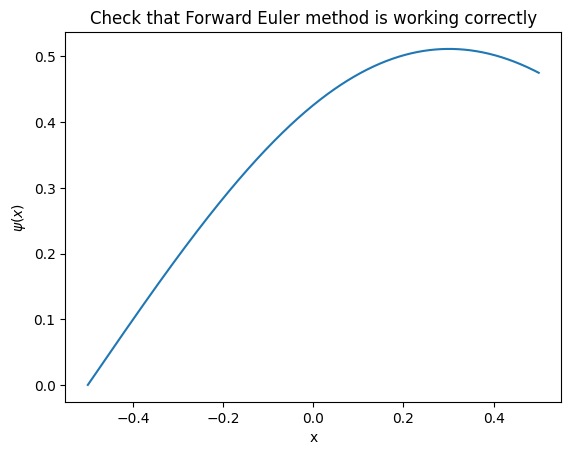

In [12]:
# define the potential as |x| between -0.5 and 0.5
def V(x):
    if x >= -0.5 and x <= 0:
        return -1*x
    elif x > 0 and x <= 0.5:
        return x
    else:
        return 1e9

# define f 
def f2(r, x, E):
    psi = r[0]
    phi = r[1]
    
    f_psi = phi 
    f_phi = (V(x) - E) * psi

    return np.array([f_psi, f_phi])

# Implement Foward Eurler Method
def FE(E, xi=-0.5, xf=0.5, n=1001):
    h = (xf - xi) / (n-1)

    x = np.linspace(xi,xf,n)

    psi = np.zeros(n)
    phi = np.zeros(n)
    psi[0] = 0 # from boundary value
    phi[0] = 1 # can be any value, determined later

    r = np.array([psi[0], phi[0]])

    for i in range(n-1):
        r = r + h*f2(r,x[i],E)
        psi[i+1] = r[0]
        phi[i+1] = r[1]

    return x, psi, phi

# check that our Foward Euler function is working as expected
x, psi, phi = FE(4)

plt.plot(x,psi)
plt.title('Check that Forward Euler method is working correctly')
plt.xlabel('x')
plt.ylabel(r'$\psi(x)$')

I can use the same secant method function I defined in question 1 to implement the shooting method. In this case, the last value in the $\psi$ array should be 0, so $g(\alpha)$ will be just be the last value returned from the Forward Euler method.

In [25]:
# define g(alpha) function that I want to find the root of
def ga2(E):
    x, psi, phi = FE(E)
    return psi[-1]

# find the apprpriate ground state energy. 4 was too small so I use it and a larger number as my initial guesses
E_actual = Secant(ga2, 4, 10)

# solve for the ground state eigenfuction using the accurate energy
x, psi, phi = FE(E_actual)

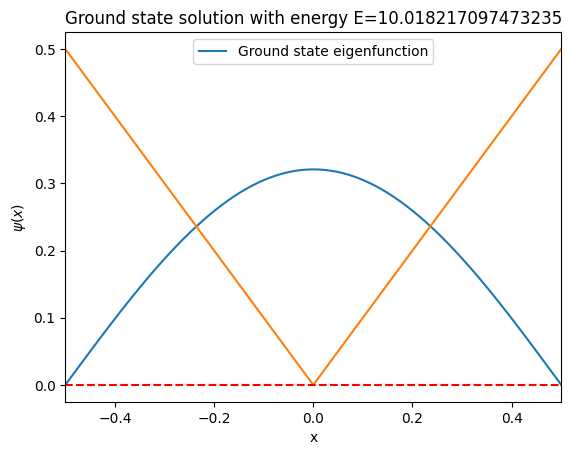

In [27]:
V = np.vectorize(V)
potential = V(x)
plt.plot(x,psi, label='Ground state eigenfunction')
plt.plot(x,potential)
plt.axhline(y=0, ls='--', c='r')
plt.xlim(-0.5,0.5)
plt.title(f'Ground state solution with energy E={E_actual}')
plt.xlabel('x')
plt.ylabel(r'$\psi(x)$')
plt.legend()